# Proyecto: Clasificación de reseñas de películas (IMDB)

Film Junky Union, una nueva comunidad vanguardista para los aficionados de las películas clásicas, está desarrollando un sistema para filtrar y categorizar reseñas de películas. El objetivo es entrenar un modelo para detectar automáticamente las críticas negativas utilizando un conjunto de datos de reseñas de películas de IMDB con etiquetado de polaridad.

**Objetivo:** Construir un modelo que clasifique reseñas como positivas o negativas con un F1 >= 0.85.

**Modelos a evaluar:**
| # | Modelo | Tipo |
|---|--------|------|
| 0 | DummyClassifier | Baseline |
| 1 | TF-IDF (word 1-2) + Logistic Regression | Clásico |
| 2 | TF-IDF (char 3-5) + Logistic Regression | Clásico |
| 3 | TF-IDF (word 1-2) + Random Forest | Clásico |
| 4 | TF-IDF (word 1-2) + Complement Naive Bayes | Clásico |
| 5 | spaCy + TF-IDF + LGBMClassifier | Gradient Boosting |
| 6 | BERT embeddings + Logistic Regression | Deep Learning |

## 1. Inicializacion

In [3]:
# Librerías básicas
import math
import time
import random
import string
import itertools
import warnings
warnings.filterwarnings('ignore')

# Librerías de exploración de datos
import numpy as np
import pandas as pd

# Scikit-Learn: modelos de ML
from sklearn.dummy import DummyClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import ComplementNB

# Scikit-Learn: vectorización de texto
from sklearn.feature_extraction.text import TfidfVectorizer
import sklearn.metrics as metrics
from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, roc_auc_score
)

# LightGBM (modelo de descenso de gradiente)
from lightgbm import LGBMClassifier

# Modelos de Deep Learning
import torch
import transformers

# Limpieza de texto
import re
import html
import unicodedata
import spacy

# Librerías para gráficos
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns

from tqdm.auto import tqdm

# Variables reutilizables
RANDOM_STATE = 123456
np.random.seed(RANDOM_STATE)

N_JOBS = -1
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# Identificación de presencia de dispositivo CUDA
print(f'PyTorch device: {DEVICE}')
if DEVICE.type == 'cuda':
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

resultados = []

PyTorch device: cuda
GPU: NVIDIA GeForce RTX 4080 SUPER
VRAM: 17.2 GB


In [4]:
%matplotlib inline
%config InlineBackend.figure_format = 'png'

# Carga en la plataforma o local
try:
    plt.style.use('seaborn')
except Exception:
    plt.style.use('seaborn-v0_8')

# esto es para usar progress_apply, puedes leer más en https://pypi.org/project/tqdm/#pandas-integration
tqdm.pandas()

## 2. Cargar datos

In [5]:
# Carga del dataset (plataforma TripleTen o ruta local)
try:
    df_reviews = pd.read_csv('/datasets/imdb_reviews.tsv', sep='\t', dtype={'votes': 'Int64'})
except Exception:
    df_reviews = pd.read_csv(
        r'P:\0 - Data Science\0 - TripleTen\Proyectos\Sprint 17\imdb_reviews.tsv',
        sep='\t', dtype={'votes': 'Int64'}
    )

print(f'Shape: {df_reviews.shape}')
df_reviews.head()

Shape: (47331, 17)


,tconst,title_type,primary_title,original_title,start_year,end_year,runtime_minutes,is_adult,genres,average_rating,votes,review,rating,sp,pos,ds_part,idx
0,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,The pakage implies that Warren Beatty and Gold...,1,neg,0,train,8335
1,tt0068152,movie,$,$,1971,\N,121,0,"Comedy,Crime,Drama",6.3,2218,How the hell did they get this made?! Presenti...,1,neg,0,train,8336
2,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,There is no real story the film seems more lik...,3,neg,0,test,2489
3,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,Um .... a serious film about troubled teens in...,7,pos,1,test,9280
4,tt0313150,short,'15','15',2002,\N,25,0,"Comedy,Drama,Short",6.3,184,I'm totally agree with GarryJohal from Singapo...,9,pos,1,test,9281


## 3. EDA

### Peliculas y reseñas a lo largo de los años

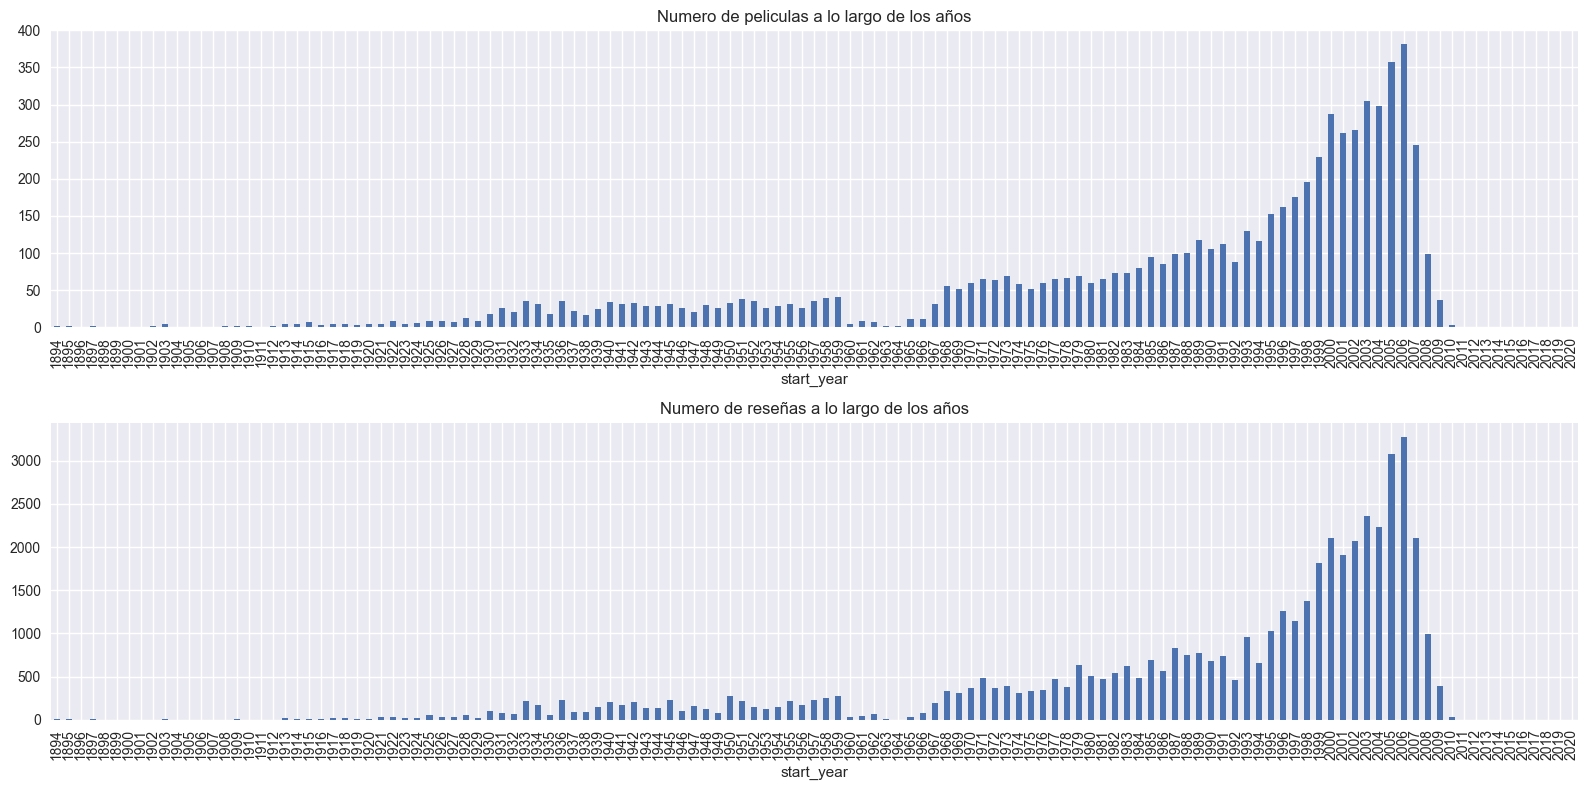

In [6]:
# Creamos 2 subgráficos organizados en una cuadrícula
fig, axs = plt.subplots(2, 1, figsize=(16, 8))

# Definimos el primer gráfico
ax = axs[0]
dft1 = df_reviews[['tconst', 'start_year']].drop_duplicates() \
    ['start_year'].value_counts().sort_index()
dft1 = dft1.reindex(index=np.arange(dft1.index.min(), max(dft1.index.max(), 2021))).fillna(0)
dft1.plot(kind='bar', ax=ax)
ax.set_title('Numero de peliculas a lo largo de los años')

# Definimos el segundo gráfico
ax = axs[1]
dft2 = df_reviews.groupby('start_year')['review'].count()
dft2 = dft2.reindex(index=np.arange(dft2.index.min(), max(dft2.index.max(), 2021))).fillna(0)
dft2.plot(kind='bar', ax=ax)
ax.set_title('Numero de reseñas a lo largo de los años')

fig.tight_layout()

Se observa un declive en los 60s tanto en reseñas como en películas, coincidiendo con el colapso de la industria cinematográfica de esa década.

Se observa a partir de los 70 una tendencia al alza en la cantidad de producción de películas hasta llegar al máximo en el año 2007, seguido de un rápido declive en los años posteriores. Sería interesante explorar las posibles causas de esta caída analizando los datos de esos años.

### Distribucion de reseñas por pelicula

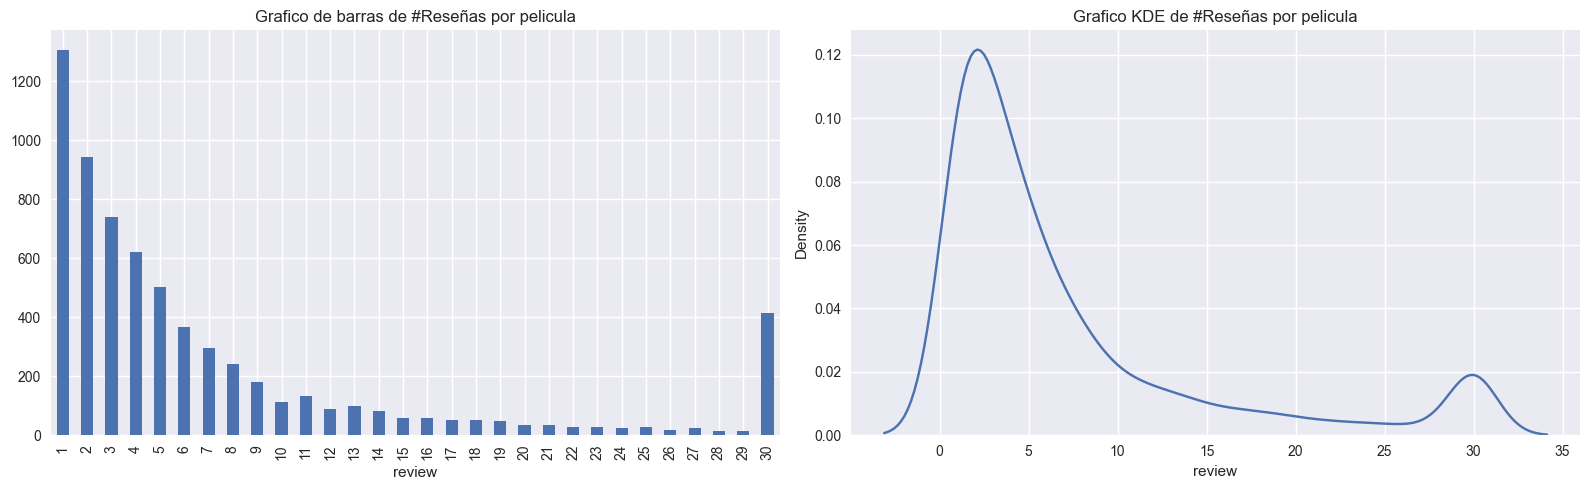

In [7]:
# Creamos 2 subgráficos organizados en una cuadrícula
fig, axs = plt.subplots(1, 2, figsize=(16, 5))

# Definimos el primer gráfico
ax = axs[0]
dft = df_reviews.groupby('tconst')['review'].count().value_counts().sort_index()
dft.plot.bar(ax=ax)
ax.set_title('Grafico de barras de #Reseñas por pelicula')

# Definimos el segundo gráfico
ax = axs[1]
dft = df_reviews.groupby('tconst')['review'].count()
sns.kdeplot(dft, ax=ax)
ax.set_title('Grafico KDE de #Reseñas por pelicula')
fig.tight_layout()

En el gráfico podemos apreciar que la mayoría de las películas tienen pocas reseñas. La distribución tiene una cola larga hacia la derecha, con un pico notable alrededor de 30 reseñas.

### Balance de clases

In [8]:
# Revisión de balance de clases
print('Conteo de clases:')
print(df_reviews['pos'].value_counts(), '\n')
print('Distribución porcentual:')
print((df_reviews['pos'].value_counts() / len(df_reviews) * 100).round(2))

Conteo de clases:
pos
0    23715
1    23616
Name: count, dtype: int64 

Distribución porcentual:
pos
0    50.1
1    49.9
Name: count, dtype: float64


### Distribucion de puntuaciones: Train vs Test

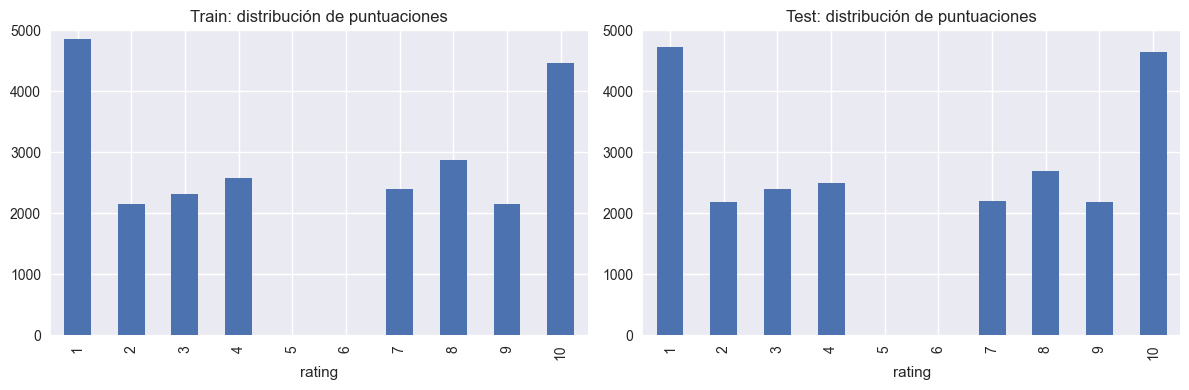

In [9]:
# Comparación de distribución de puntuaciones entre train y test
fig, axs = plt.subplots(1, 2, figsize=(12, 4))

ax = axs[0]
dft = df_reviews.query('ds_part == "train"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Train: distribución de puntuaciones')

ax = axs[1]
dft = df_reviews.query('ds_part == "test"')['rating'].value_counts().sort_index()
dft = dft.reindex(index=np.arange(min(dft.index.min(), 1), max(dft.index.max(), 11))).fillna(0)
dft.plot.bar(ax=ax)
ax.set_ylim([0, 5000])
ax.set_title('Test: distribución de puntuaciones')
fig.tight_layout()

Los conjuntos de entrenamiento y prueba tienen distribuciones de puntuaciones muy similares, lo que asegura una evaluación confiable de los modelos.

### Reseñas por polaridad y año: Train vs Test

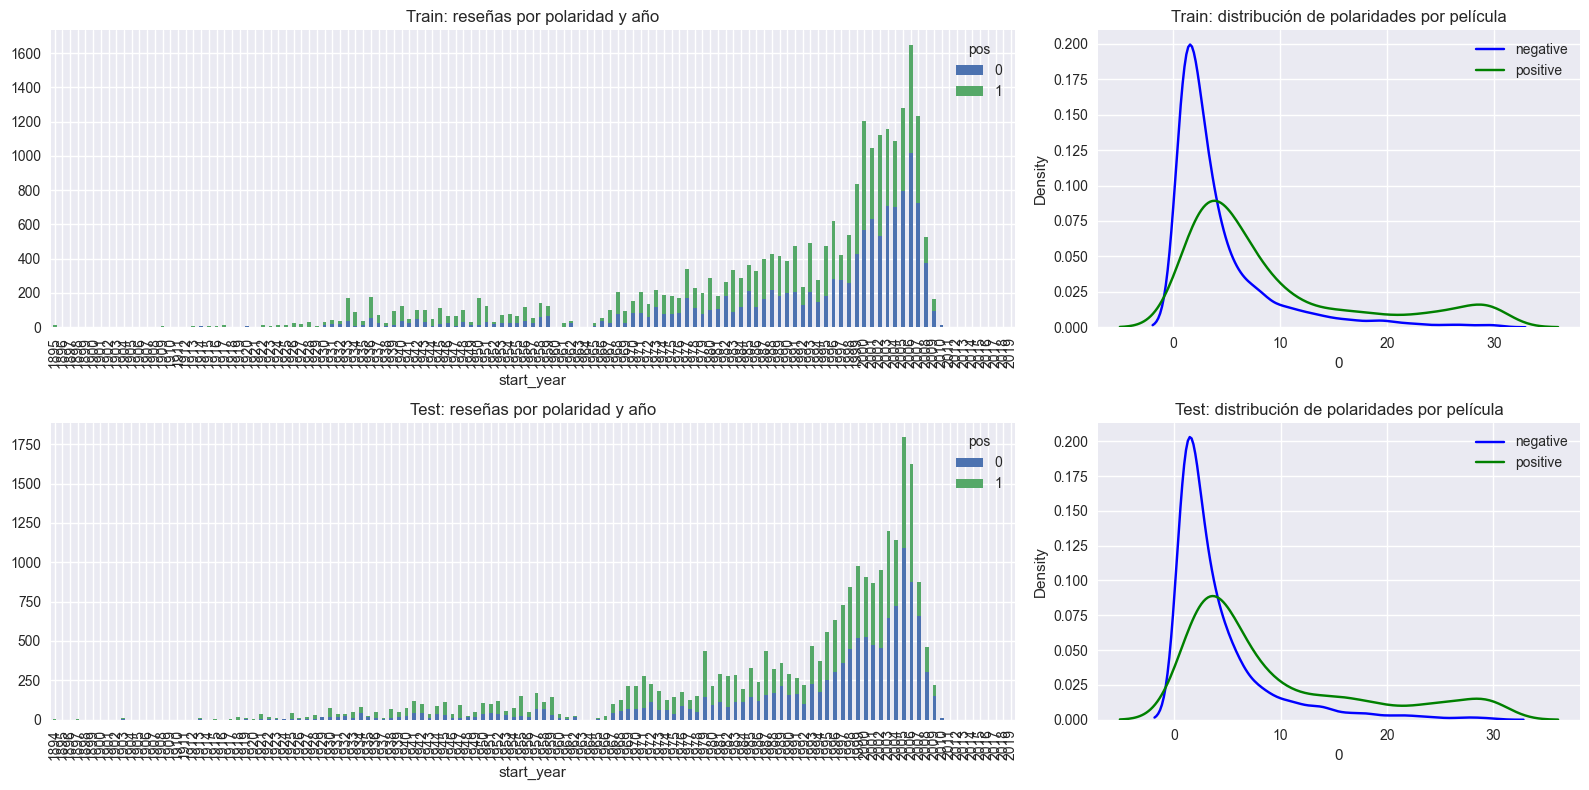

In [10]:
# Reseñas por polaridad y año, comparando train vs test
fig, axs = plt.subplots(2, 2, figsize=(16, 8),
                         gridspec_kw=dict(width_ratios=(2, 1), height_ratios=(1, 1)))

for row, part in enumerate(['train', 'test']):
    # Gráfico de barras apiladas: reseñas positivas y negativas por año
    ax = axs[row][0]
    dft = df_reviews.query(f'ds_part == "{part}"').groupby(
        ['start_year', 'pos'])['pos'].count().unstack()
    dft.index = dft.index.astype('int')
    dft = dft.reindex(index=np.arange(dft.index.min(), max(dft.index.max(), 2020))).fillna(0)
    dft.plot(kind='bar', stacked=True, ax=ax)
    ax.set_title(f'{part.title()}: reseñas por polaridad y año')

    # Gráfico KDE: distribución de polaridades por película
    ax = axs[row][1]
    dft = df_reviews.query(f'ds_part == "{part}"').groupby(
        ['tconst', 'pos'])['pos'].count().unstack()
    sns.kdeplot(dft[0], color='blue', label='negative', kernel='epa', ax=ax)
    sns.kdeplot(dft[1], color='green', label='positive', kernel='epa', ax=ax)
    ax.legend()
    ax.set_title(f'{part.title()}: distribución de polaridades por película')

fig.tight_layout()

## 4. Funciones de evaluacion

In [11]:
def evaluate_model(model, train_features, train_target, test_features, test_target):
    """Genera graficos de F1 vs umbral, curva ROC y curva PRC."""
    eval_stats = {}
    fig, axs = plt.subplots(1, 3, figsize=(20, 6))

    for tipo, features, target in (
        ('train', train_features, train_target),
        ('test', test_features, test_target)
    ):
        eval_stats[tipo] = {}
        pred_target = model.predict(features)
        pred_proba = model.predict_proba(features)[:, 1]

        f1_thresholds = np.arange(0, 1.01, 0.05)
        f1_scores = [metrics.f1_score(target, pred_proba >= th) for th in f1_thresholds]

        fpr, tpr, roc_thresholds = metrics.roc_curve(target, pred_proba)
        roc_auc = metrics.roc_auc_score(target, pred_proba)
        eval_stats[tipo]['ROC AUC'] = roc_auc

        precision, recall, pr_thresholds = metrics.precision_recall_curve(target, pred_proba)
        aps = metrics.average_precision_score(target, pred_proba)
        eval_stats[tipo]['APS'] = aps

        color = 'blue' if tipo == 'train' else 'green'

        ax = axs[0]
        max_idx = np.argmax(f1_scores)
        ax.plot(f1_thresholds, f1_scores, color=color,
                label=f'{tipo}, max={f1_scores[max_idx]:.2f} @ {f1_thresholds[max_idx]:.2f}')
        for th in (0.2, 0.4, 0.5, 0.6, 0.8):
            idx = np.argmin(np.abs(f1_thresholds - th))
            mc = 'red' if th == 0.5 else 'orange'
            ax.plot(f1_thresholds[idx], f1_scores[idx], color=mc, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('Umbral'); ax.set_ylabel('F1')
        ax.legend(loc='lower center'); ax.set_title('F1 vs Umbral')

        ax = axs[1]
        ax.plot(fpr, tpr, color=color, label=f'{tipo}, ROC AUC={roc_auc:.2f}')
        for th in (0.2, 0.4, 0.5, 0.6, 0.8):
            idx = np.argmin(np.abs(roc_thresholds - th))
            mc = 'red' if th == 0.5 else 'orange'
            ax.plot(fpr[idx], tpr[idx], color=mc, marker='X', markersize=7)
        ax.plot([0, 1], [0, 1], color='grey', linestyle='--')
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('FPR'); ax.set_ylabel('TPR')
        ax.legend(loc='lower center'); ax.set_title('Curva ROC')

        ax = axs[2]
        ax.plot(recall, precision, color=color, label=f'{tipo}, AP={aps:.2f}')
        for th in (0.2, 0.4, 0.5, 0.6, 0.8):
            idx = np.argmin(np.abs(pr_thresholds - th))
            mc = 'red' if th == 0.5 else 'orange'
            ax.plot(recall[idx], precision[idx], color=mc, marker='X', markersize=7)
        ax.set_xlim([-0.02, 1.02]); ax.set_ylim([-0.02, 1.02])
        ax.set_xlabel('Recall'); ax.set_ylabel('Precision')
        ax.legend(loc='lower center'); ax.set_title('Curva PRC')

        eval_stats[tipo]['Accuracy'] = metrics.accuracy_score(target, pred_target)
        eval_stats[tipo]['F1'] = metrics.f1_score(target, pred_target)

    df_eval = pd.DataFrame(eval_stats).round(4)
    df_eval = df_eval.reindex(index=('Accuracy', 'F1', 'APS', 'ROC AUC'))
    print(df_eval)
    fig.tight_layout()
    return df_eval

## 5. Normalizacion de texto

Para los modelos clásicos (TF-IDF, spaCy), se aplica una normalización uniforme: minúsculas, sin dígitos ni signos de puntuación.

Para BERT se usa un preprocesamiento más ligero (solo limpieza de HTML y espacios), ya que el modelo aprovecha la puntuación y estructura original del texto.

In [12]:
# Expresiones regulares para limpieza de texto
TAG_RE = re.compile(r'<[^>]+>')
PUNCT_RE = re.compile(r'[^\w\s]')
DIGIT_RE = re.compile(r'\d+')

def normalize_text(s: str) -> str:
    """Normalización para modelos clásicos: minúsculas, sin HTML, puntuación ni dígitos."""
    if not isinstance(s, str):
        s = str(s)
    s = html.unescape(s)
    s = TAG_RE.sub(' ', s)
    s = s.lower()
    s = PUNCT_RE.sub(' ', s)
    s = DIGIT_RE.sub(' ', s)
    s = re.sub(r'\s+', ' ', s).strip()
    return s

# Aplicar normalización a todas las reseñas
df_reviews['review_norm'] = df_reviews['review'].astype(str).map(normalize_text)
df_reviews['review_norm'].head()

0    the pakage implies that warren beatty and gold...
1    how the hell did they get this made presenting...
2    there is no real story the film seems more lik...
3    um a serious film about troubled teens in sing...
4    i m totally agree with garryjohal from singapo...
Name: review_norm, dtype: object

## 6. Division Train / Test

El dataset ya viene dividido mediante la columna `ds_part`.

In [13]:
# Separar datos en train y test usando la columna ds_part
df_reviews_train = df_reviews.query('ds_part == "train"').copy()
df_reviews_test = df_reviews.query('ds_part == "test"').copy()

# Extraer las etiquetas objetivo
train_target = df_reviews_train['pos']
test_target = df_reviews_test['pos']

print(f'Train: {df_reviews_train.shape}')
print(f'Test:  {df_reviews_test.shape}')
print(f'\nBalance train: {train_target.value_counts(normalize=True).round(3).to_dict()}')
print(f'Balance test:  {test_target.value_counts(normalize=True).round(3).to_dict()}')

Train: (23796, 18)
Test:  (23535, 18)

Balance train: {0: 0.501, 1: 0.499}
Balance test:  {0: 0.502, 1: 0.498}


## 7. Entrenamiento y evaluacion de modelos

### Modelo 0 - DummyClassifier (Baseline)

In [14]:
# Features vacíos (el Dummy no necesita datos reales)
X_train_0 = np.zeros((len(df_reviews_train), 1))
X_test_0 = np.zeros((len(df_reviews_test), 1))

# Modelo baseline: siempre predice la clase más frecuente
dummy_model = DummyClassifier(random_state=RANDOM_STATE, strategy='most_frequent')

# Entrenamiento
t0 = time.perf_counter()
dummy_model.fit(X_train_0, train_target)
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_0 = dummy_model.predict(X_test_0)
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_0 = f1_score(test_target, y_pred_0)
acc_0 = accuracy_score(test_target, y_pred_0)
try:
    auc_0 = roc_auc_score(test_target, dummy_model.predict_proba(X_test_0)[:, 1])
except:
    auc_0 = 0.5

# Guardar resultados
resultados.append({
    'Modelo': '0 - Dummy (Baseline)',
    'F1 Test': round(f1_0, 4),
    'Accuracy Test': round(acc_0, 4),
    'ROC AUC Test': round(auc_0, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_0:.4f} | Accuracy: {acc_0:.4f} | ROC AUC: {auc_0:.4f}')
print(f'Tiempo train: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print('\n' + classification_report(test_target, y_pred_0, target_names=['neg', 'pos'], digits=4))

F1: 0.0000 | Accuracy: 0.5015 | ROC AUC: 0.5000
Tiempo train: 0.00s | Tiempo pred: 0.00s

              precision    recall  f1-score   support

         neg     0.5015    1.0000    0.6680     11803
         pos     0.0000    0.0000    0.0000     11732

    accuracy                         0.5015     23535
   macro avg     0.2508    0.5000    0.3340     23535
weighted avg     0.2515    0.5015    0.3350     23535



           train    test
Accuracy  0.5006  0.5015
F1        0.0000  0.0000
APS       0.4994  0.4985
ROC AUC   0.5000  0.5000


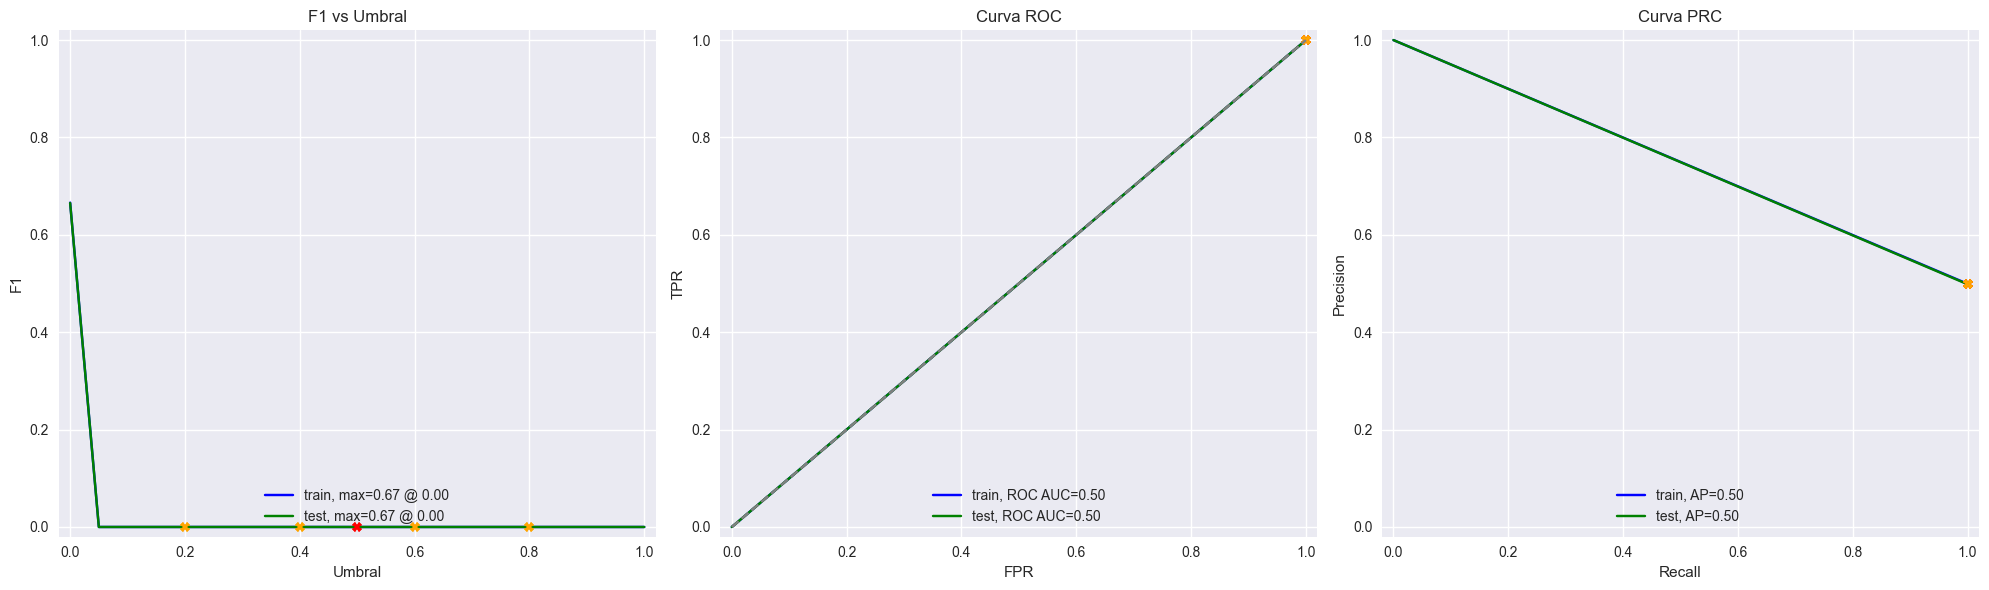

In [15]:
evaluate_model(dummy_model, X_train_0, train_target, X_test_0, test_target);

### Modelo 1 - TF-IDF (word 1-2) + Logistic Regression

In [16]:
# Vectorización TF-IDF con unigramas y bigramas de palabras
tfidf_word = TfidfVectorizer(
    ngram_range=(1, 2), min_df=2, max_df=0.9,
    stop_words='english', strip_accents='unicode'
)

# Transformar textos a vectores TF-IDF
t0 = time.perf_counter()
X_train_1 = tfidf_word.fit_transform(df_reviews_train['review_norm'])
X_test_1 = tfidf_word.transform(df_reviews_test['review_norm'])
t_vec = time.perf_counter() - t0
print(f'Vectorización: {t_vec:.2f}s | Features: {X_train_1.shape[1]:,}')

# Regresión logística con balance de clases
model_1 = LogisticRegression(
    max_iter=10000, solver='liblinear',
    class_weight='balanced', random_state=RANDOM_STATE
)

# Entrenamiento
t0 = time.perf_counter()
model_1.fit(X_train_1, train_target)
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_1 = model_1.predict(X_test_1)
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_1 = f1_score(test_target, y_pred_1)
acc_1 = accuracy_score(test_target, y_pred_1)
auc_1 = roc_auc_score(test_target, model_1.predict_proba(X_test_1)[:, 1])

# Guardar resultados
resultados.append({
    'Modelo': '1 - TF-IDF word + LR',
    'F1 Test': round(f1_1, 4),
    'Accuracy Test': round(acc_1, 4),
    'ROC AUC Test': round(auc_1, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_1:.4f} | Accuracy: {acc_1:.4f} | ROC AUC: {auc_1:.4f}')
print(f'Tiempo train: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print('\n' + classification_report(test_target, y_pred_1, target_names=['neg', 'pos'], digits=4))

Vectorización: 9.65s | Features: 290,834
F1: 0.8784 | Accuracy: 0.8783 | ROC AUC: 0.9499
Tiempo train: 0.46s | Tiempo pred: 0.01s

              precision    recall  f1-score   support

         neg     0.8815    0.8750    0.8782     11803
         pos     0.8752    0.8816    0.8784     11732

    accuracy                         0.8783     23535
   macro avg     0.8783    0.8783    0.8783     23535
weighted avg     0.8783    0.8783    0.8783     23535



           train    test
Accuracy  0.9529  0.8783
F1        0.9532  0.8784
APS       0.9903  0.9480
ROC AUC   0.9899  0.9499


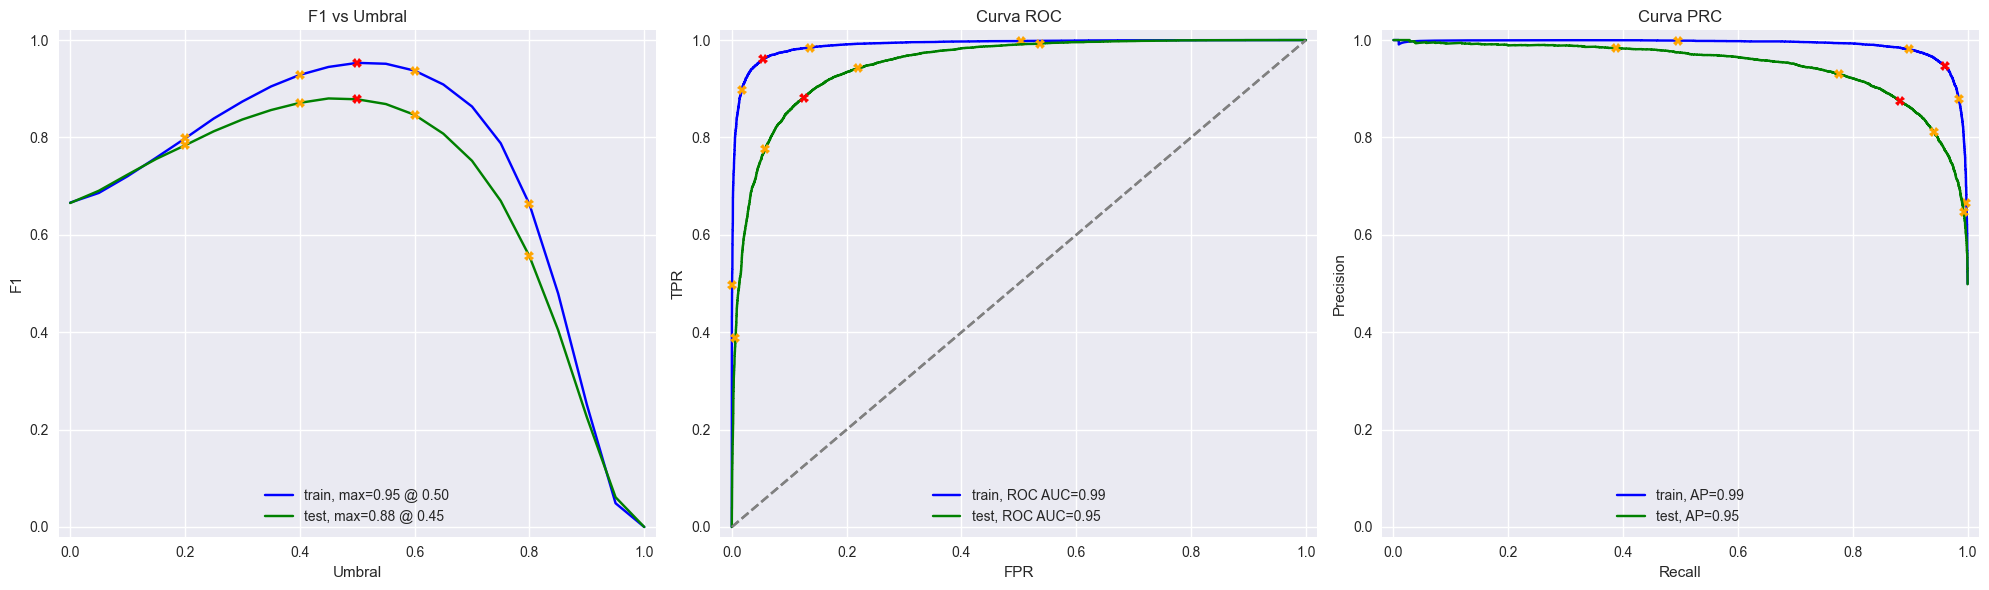

In [17]:
evaluate_model(model_1, X_train_1, train_target, X_test_1, test_target);

### Modelo 2 - TF-IDF (char 3-5) + Logistic Regression

In [18]:
# Vectorización TF-IDF con n-gramas de caracteres (3 a 5)
tfidf_char = TfidfVectorizer(analyzer='char', ngram_range=(3, 5), min_df=2)

# Transformar textos a vectores TF-IDF de caracteres
t0 = time.perf_counter()
X_train_2 = tfidf_char.fit_transform(df_reviews_train['review_norm'])
X_test_2 = tfidf_char.transform(df_reviews_test['review_norm'])
t_vec = time.perf_counter() - t0
print(f'Vectorización: {t_vec:.2f}s | Features: {X_train_2.shape[1]:,}')

# Regresión logística con balance de clases
model_2 = LogisticRegression(
    max_iter=2000, solver='liblinear',
    class_weight='balanced', random_state=RANDOM_STATE
)

# Entrenamiento
t0 = time.perf_counter()
model_2.fit(X_train_2, train_target)
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_2 = model_2.predict(X_test_2)
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_2 = f1_score(test_target, y_pred_2)
acc_2 = accuracy_score(test_target, y_pred_2)
auc_2 = roc_auc_score(test_target, model_2.predict_proba(X_test_2)[:, 1])

# Guardar resultados
resultados.append({
    'Modelo': '2 - TF-IDF char + LR',
    'F1 Test': round(f1_2, 4),
    'Accuracy Test': round(acc_2, 4),
    'ROC AUC Test': round(auc_2, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_2:.4f} | Accuracy: {acc_2:.4f} | ROC AUC: {auc_2:.4f}')
print(f'Tiempo train: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print('\n' + classification_report(test_target, y_pred_2, target_names=['neg', 'pos'], digits=4))

Vectorización: 65.53s | Features: 261,110
F1: 0.8844 | Accuracy: 0.8847 | ROC AUC: 0.9546
Tiempo train: 7.19s | Tiempo pred: 0.11s

              precision    recall  f1-score   support

         neg     0.8850    0.8852    0.8851     11803
         pos     0.8845    0.8842    0.8844     11732

    accuracy                         0.8847     23535
   macro avg     0.8847    0.8847    0.8847     23535
weighted avg     0.8847    0.8847    0.8847     23535



           train    test
Accuracy  0.9334  0.8847
F1        0.9337  0.8844
APS       0.9816  0.9535
ROC AUC   0.9813  0.9546


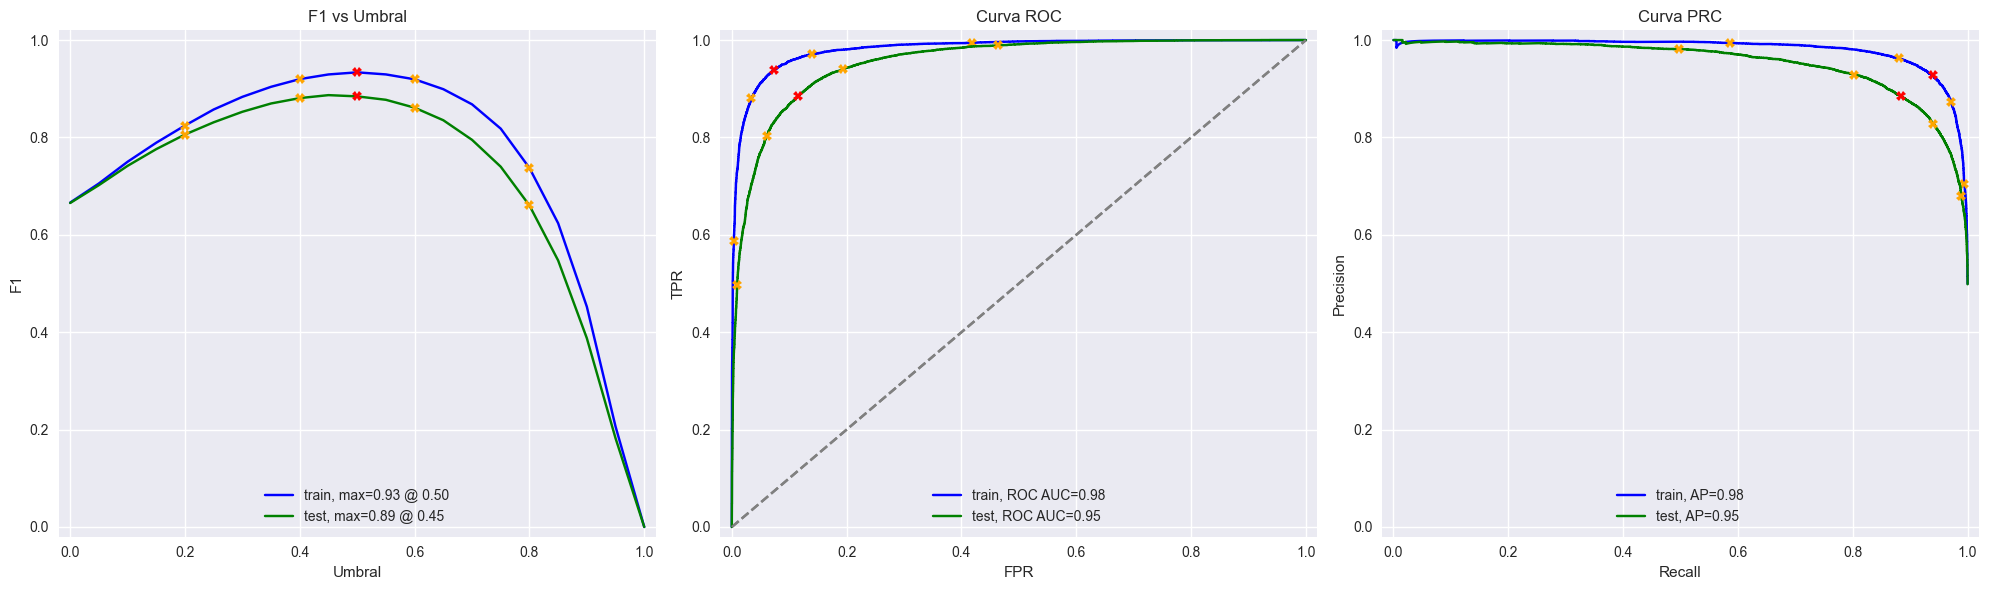

In [19]:
evaluate_model(model_2, X_train_2, train_target, X_test_2, test_target);

### Modelo 3 - TF-IDF (word 1-2) + Random Forest

In [20]:
# Random Forest con 200 árboles y balance de clases
model_3 = RandomForestClassifier(
    n_estimators=200, max_depth=None,
    class_weight='balanced', random_state=RANDOM_STATE,
    n_jobs=N_JOBS
)

# Entrenamiento (usa los mismos vectores TF-IDF word del Modelo 1)
t0 = time.perf_counter()
model_3.fit(X_train_1, train_target)
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_3 = model_3.predict(X_test_1)
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_3 = f1_score(test_target, y_pred_3)
acc_3 = accuracy_score(test_target, y_pred_3)
auc_3 = roc_auc_score(test_target, model_3.predict_proba(X_test_1)[:, 1])

# Guardar resultados
resultados.append({
    'Modelo': '3 - TF-IDF word + RF',
    'F1 Test': round(f1_3, 4),
    'Accuracy Test': round(acc_3, 4),
    'ROC AUC Test': round(auc_3, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_3:.4f} | Accuracy: {acc_3:.4f} | ROC AUC: {auc_3:.4f}')
print(f'Tiempo train: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print('\n' + classification_report(test_target, y_pred_3, target_names=['neg', 'pos'], digits=4))

F1: 0.8564 | Accuracy: 0.8582 | ROC AUC: 0.9342
Tiempo train: 15.33s | Tiempo pred: 1.48s

              precision    recall  f1-score   support

         neg     0.8521    0.8678    0.8599     11803
         pos     0.8645    0.8484    0.8564     11732

    accuracy                         0.8582     23535
   macro avg     0.8583    0.8581    0.8581     23535
weighted avg     0.8583    0.8582    0.8582     23535



          train    test
Accuracy    1.0  0.8582
F1          1.0  0.8564
APS         1.0  0.9272
ROC AUC     1.0  0.9342


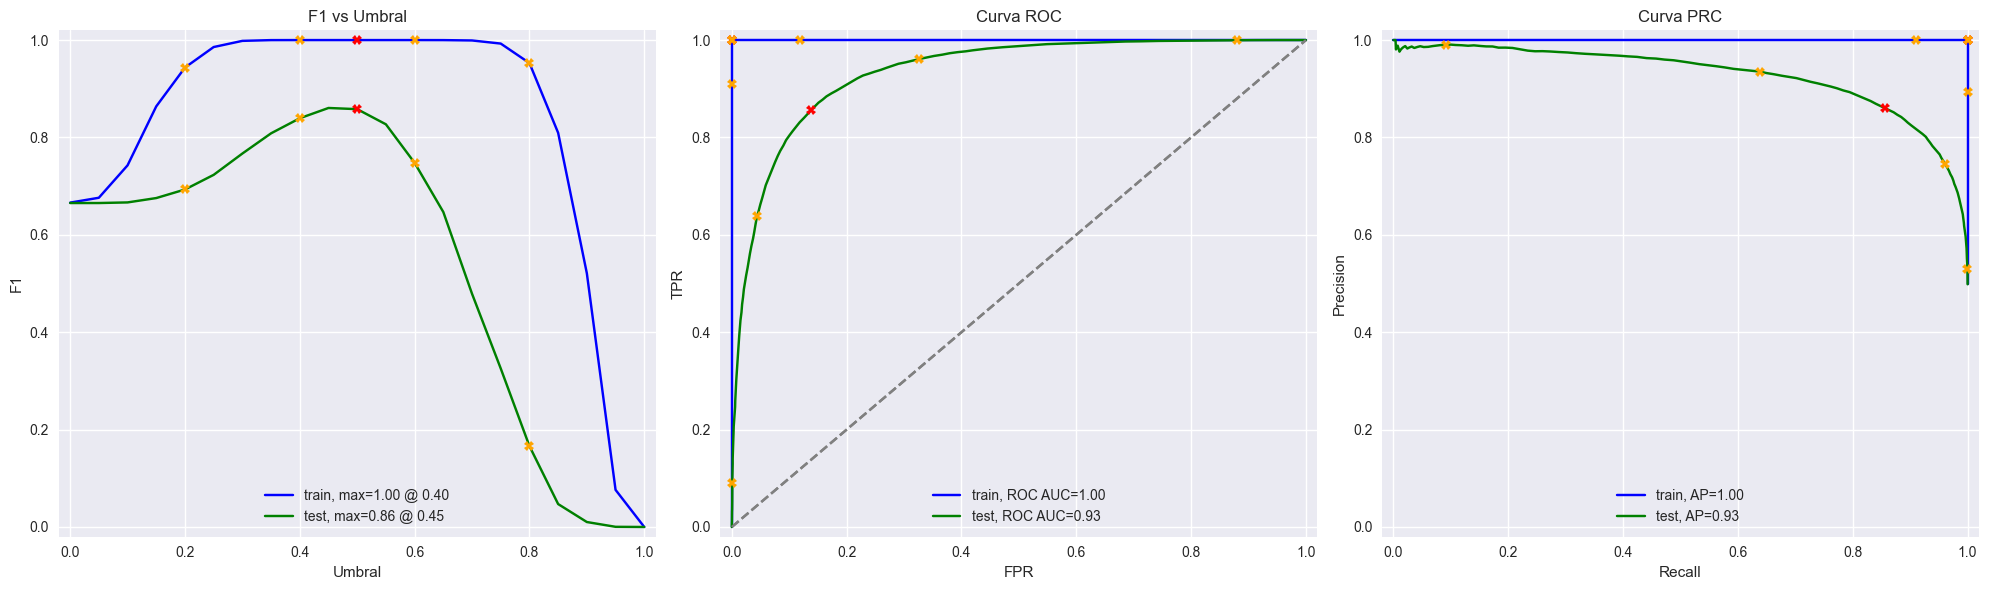

In [21]:
evaluate_model(model_3, X_train_1, train_target, X_test_1, test_target);

### Modelo 4 - TF-IDF (word 1-2) + Complement Naive Bayes

In [22]:
# Complement Naive Bayes (optimizado para datos desbalanceados)
model_4 = ComplementNB()

# Entrenamiento (usa los mismos vectores TF-IDF word del Modelo 1)
t0 = time.perf_counter()
model_4.fit(X_train_1, train_target)
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_4 = model_4.predict(X_test_1)
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_4 = f1_score(test_target, y_pred_4)
acc_4 = accuracy_score(test_target, y_pred_4)
auc_4 = roc_auc_score(test_target, model_4.predict_proba(X_test_1)[:, 1])

# Guardar resultados
resultados.append({
    'Modelo': '4 - TF-IDF word + CNB',
    'F1 Test': round(f1_4, 4),
    'Accuracy Test': round(acc_4, 4),
    'ROC AUC Test': round(auc_4, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_4:.4f} | Accuracy: {acc_4:.4f} | ROC AUC: {auc_4:.4f}')
print(f'Tiempo train: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print('\n' + classification_report(test_target, y_pred_4, target_names=['neg', 'pos'], digits=4))

F1: 0.8450 | Accuracy: 0.8509 | ROC AUC: 0.9304
Tiempo train: 0.04s | Tiempo pred: 0.03s

              precision    recall  f1-score   support

         neg     0.8281    0.8869    0.8565     11803
         pos     0.8775    0.8148    0.8450     11732

    accuracy                         0.8509     23535
   macro avg     0.8528    0.8508    0.8507     23535
weighted avg     0.8527    0.8509    0.8507     23535



           train    test
Accuracy  0.9558  0.8509
F1        0.9557  0.8450
APS       0.9910  0.9254
ROC AUC   0.9906  0.9304


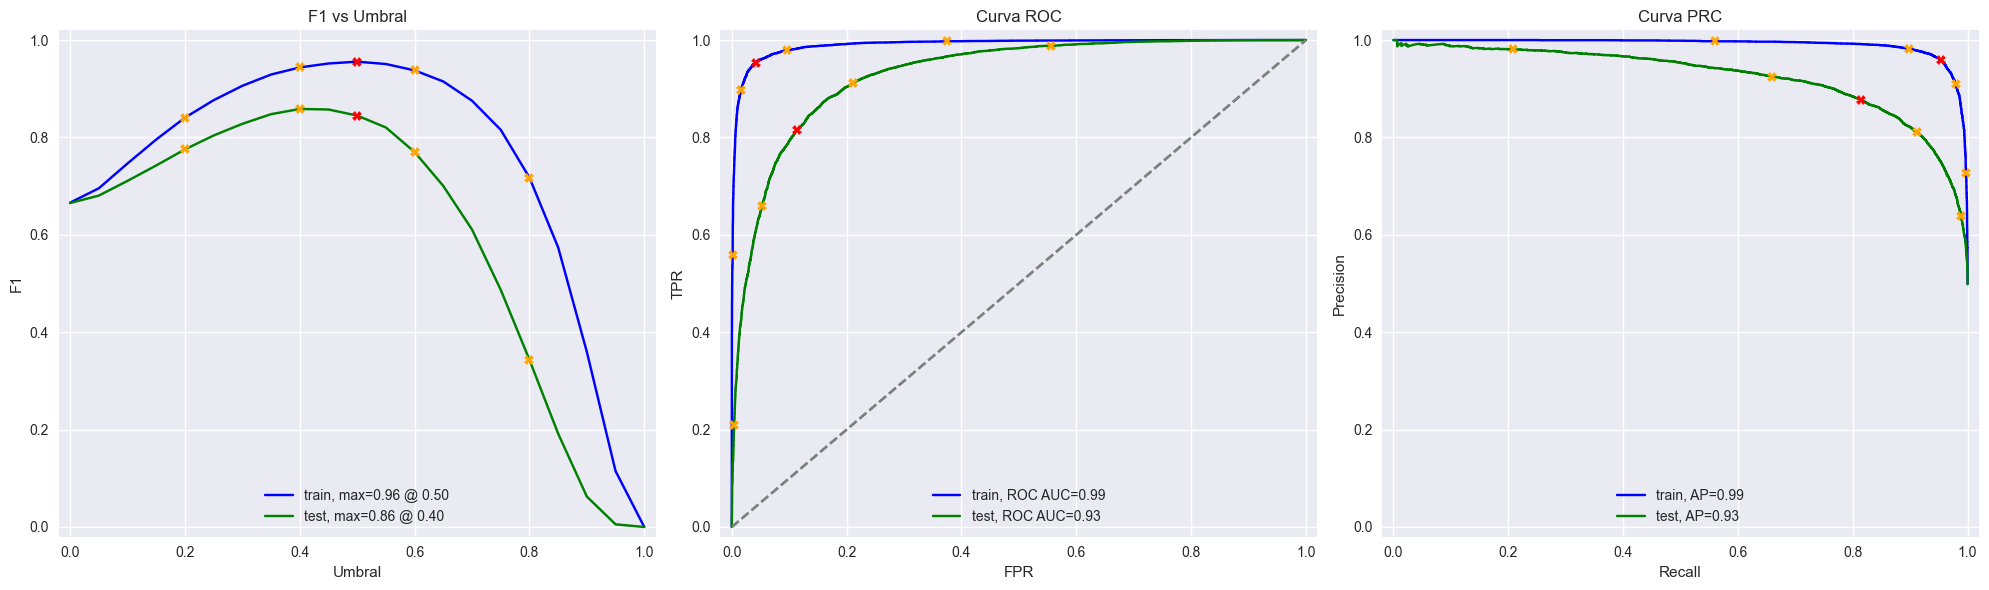

In [23]:
evaluate_model(model_4, X_train_1, train_target, X_test_1, test_target);

### Modelo 5 - spaCy + TF-IDF + LGBMClassifier

In [24]:
# Cargar modelo de spaCy para lematización
try:
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'textcat'])
except OSError:
    print('Modelo spaCy no encontrado. Descargando...')
    spacy.cli.download('en_core_web_sm')
    nlp = spacy.load('en_core_web_sm', disable=['parser', 'ner', 'textcat'])

def spacy_lemmas(text):
    """Tokeniza y lematiza con spaCy, filtrando stopwords y puntuación."""
    doc = nlp(str(text).lower().strip())
    return [t.lemma_ for t in doc
            if not (t.is_space or t.is_punct or t.like_num or t.is_stop)]

# Vectorización TF-IDF usando lemas de spaCy como tokens
tfidf_spacy = TfidfVectorizer(
    tokenizer=spacy_lemmas,
    preprocessor=None,
    lowercase=False,
    ngram_range=(1, 2),
    min_df=3, max_df=0.9,
    sublinear_tf=True,
    max_features=50_000
)

# Transformar textos a vectores TF-IDF con lematización
print('Vectorizando con spaCy (esto toma unos minutos)...')
t0 = time.perf_counter()
X_train_5 = tfidf_spacy.fit_transform(df_reviews_train['review_norm'])
X_test_5 = tfidf_spacy.transform(df_reviews_test['review_norm'])
t_vec = time.perf_counter() - t0
print(f'Vectorización: {t_vec:.1f}s | Features: {X_train_5.shape[1]:,}')

Vectorizando con spaCy (esto toma unos minutos)...
Vectorización: 888.1s | Features: 50,000


In [25]:
# LightGBM con descenso de gradiente para clasificación binaria
model_5 = LGBMClassifier(
    objective='binary',
    class_weight='balanced',
    random_state=RANDOM_STATE,
    n_estimators=600,
    learning_rate=0.05,
    num_leaves=63,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    n_jobs=N_JOBS,
    verbose=-1
)

# Entrenamiento
t0 = time.perf_counter()
model_5.fit(X_train_5, train_target.astype(int))
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_5 = model_5.predict(X_test_5)
y_proba_5 = model_5.predict_proba(X_test_5)[:, 1]
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_5 = f1_score(test_target, y_pred_5)
acc_5 = accuracy_score(test_target, y_pred_5)
auc_5 = roc_auc_score(test_target, y_proba_5)

# Guardar resultados
resultados.append({
    'Modelo': '5 - spaCy + LGBM',
    'F1 Test': round(f1_5, 4),
    'Accuracy Test': round(acc_5, 4),
    'ROC AUC Test': round(auc_5, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_5:.4f} | Accuracy: {acc_5:.4f} | ROC AUC: {auc_5:.4f}')
print(f'Tiempo train: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print('\n' + classification_report(test_target, y_pred_5, target_names=['neg', 'pos'], digits=4))
print('Matriz de confusión:\n', confusion_matrix(test_target, y_pred_5))

F1: 0.8717 | Accuracy: 0.8723 | ROC AUC: 0.9456
Tiempo train: 69.11s | Tiempo pred: 0.69s

              precision    recall  f1-score   support

         neg     0.8714    0.8744    0.8729     11803
         pos     0.8732    0.8702    0.8717     11732

    accuracy                         0.8723     23535
   macro avg     0.8723    0.8723    0.8723     23535
weighted avg     0.8723    0.8723    0.8723     23535

Matriz de confusión:
 [[10320  1483]
 [ 1523 10209]]


          train    test
Accuracy    1.0  0.8723
F1          1.0  0.8717
APS         1.0  0.9435
ROC AUC     1.0  0.9456


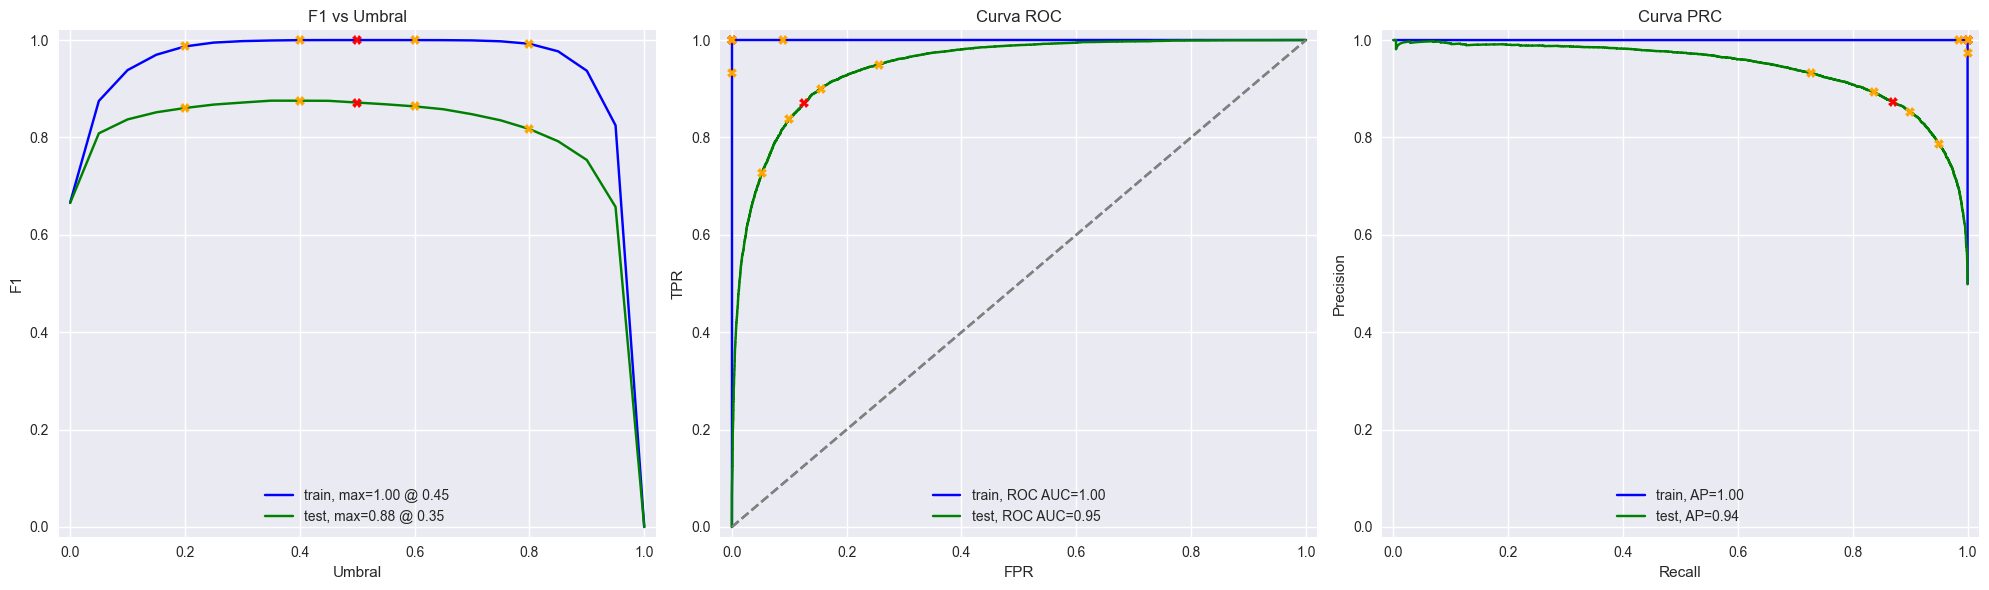

In [26]:
evaluate_model(model_5, X_train_5, train_target, X_test_5, test_target);

### Modelo 6 - BERT embeddings + Logistic Regression

Se genera un embedding por reseña usando **mean pooling** (promedio de todos los tokens, excluyendo padding) de BERT. A diferencia de los modelos anteriores, se usa un preprocesamiento ligero que conserva la puntuación y estructura del texto original.

**Optimización GPU:** batch_size=100, mixed precision (fp16) en RTX 4080.

In [27]:
# Cargar tokenizer (convierte texto a tokens numéricos que BERT entiende)
bert_tokenizer = transformers.BertTokenizer.from_pretrained('bert-base-uncased')

# Cargar configuración del modelo (arquitectura, número de capas, etc.)
bert_config = transformers.BertConfig.from_pretrained('bert-base-uncased')

# Cargar modelo BERT pre-entrenado (solo el encoder, sin cabezas de clasificación)
bert_model = transformers.BertModel.from_pretrained('bert-base-uncased')

# Expresión regular para limpiar etiquetas HTML
TAG_RE_BERT = re.compile(r'<[^>]+>')

def normalize_for_bert(s: str) -> str:
    """Limpieza mínima para BERT: solo HTML y espacios.
    A diferencia de normalize_text(), conserva puntuación y mayúsculas
    porque BERT las aprovecha para entender mejor el contexto.
    """
    if not isinstance(s, str):
        s = str(s)
    s = html.unescape(s)                # Decodificar entidades HTML (&amp; → &)
    s = TAG_RE_BERT.sub(' ', s)         # Eliminar etiquetas HTML (<br>, <p>, etc.)
    s = re.sub(r'\s+', ' ', s).strip()  # Normalizar espacios múltiples
    return s


def bert_text_to_embeddings(texts, max_length=512, batch_size=100):
    """Convierte una lista de textos a vectores numéricos de 768 dimensiones
    usando BERT con mean pooling (promedio de todos los tokens).
    """
    device = DEVICE

    # Mover modelo a GPU/CPU y ponerlo en modo evaluación (desactiva dropout)
    bert_model.to(device)
    bert_model.eval()

    embeddings = []
    text_list = list(texts)

    # Procesar en lotes para no saturar la memoria de la GPU
    for i in tqdm(range(0, len(text_list), batch_size), desc='BERT embeddings'):
        batch_texts = text_list[i:i + batch_size]

        # Tokenizar: convierte texto a IDs numéricos con padding y truncamiento
        encoded = bert_tokenizer(
            batch_texts,
            padding=True,       # Rellenar textos cortos para igualar longitud del batch
            truncation=True,    # Cortar textos que excedan max_length
            max_length=max_length,
            return_tensors='pt' # Devolver tensores de PyTorch
        )

        # Mover tensores al mismo dispositivo que el modelo (GPU/CPU)
        input_ids = encoded['input_ids'].to(device)
        attention_mask = encoded['attention_mask'].to(device)  # 1 = token real, 0 = padding

        # Inferencia sin calcular gradientes (ahorra memoria y acelera)
        with torch.no_grad():
            # Mixed precision (fp16) en GPU para mayor velocidad
            if device.type == 'cuda':
                with torch.amp.autocast('cuda'):
                    outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)
            else:
                outputs = bert_model(input_ids=input_ids, attention_mask=attention_mask)

        # Mean pooling: promedio de todos los tokens reales (excluyendo padding)
        # Esto da una mejor representación que usar solo el token [CLS]
        hidden = outputs.last_hidden_state.float()       # (batch, seq_len, 768)
        mask = attention_mask.unsqueeze(-1).float()       # (batch, seq_len, 1)
        mean_emb = (hidden * mask).sum(dim=1) / mask.sum(dim=1)  # (batch, 768)
        embeddings.append(mean_emb.cpu().numpy())

    # Concatenar todos los lotes en una sola matriz
    return np.concatenate(embeddings)

# Preprocesamiento ligero para BERT (conserva puntuación y estructura del texto)
df_reviews_train['review_bert'] = df_reviews_train['review'].astype(str).map(normalize_for_bert)
df_reviews_test['review_bert'] = df_reviews_test['review'].astype(str).map(normalize_for_bert)

# Generar embeddings para train
print(f'Dispositivo: {DEVICE}')
print(f'Generando embeddings para {len(df_reviews_train)} textos de train...')

t0 = time.perf_counter()
train_features_bert = bert_text_to_embeddings(df_reviews_train['review_bert'])
t_embed_train = time.perf_counter() - t0
print(f'Train embeddings: {train_features_bert.shape} en {t_embed_train:.1f}s')

# Generar embeddings para test
print(f'\nGenerando embeddings para {len(df_reviews_test)} textos de test...')
t0 = time.perf_counter()
test_features_bert = bert_text_to_embeddings(df_reviews_test['review_bert'])
t_embed_test = time.perf_counter() - t0
print(f'Test embeddings: {test_features_bert.shape} en {t_embed_test:.1f}s')

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 4719.23it/s]
BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Dispositivo: cuda
Generando embeddings para 23796 textos de train...


BERT embeddings: 100%|██████████| 238/238 [00:50<00:00,  4.70it/s]


Train embeddings: (23796, 768) en 51.0s

Generando embeddings para 23535 textos de test...


BERT embeddings: 100%|██████████| 236/236 [00:51<00:00,  4.60it/s]

Test embeddings: (23535, 768) en 51.3s


In [28]:
# Guardar embeddings para no recalcularlos
np.savez_compressed(
    'bert_embeddings.npz',
    train=train_features_bert,
    test=test_features_bert
)
print('Embeddings guardados en bert_embeddings.npz')

Embeddings guardados en bert_embeddings.npz


In [29]:
# Para cargar embeddings previamente calculados (descomenta si ya existen):
# data = np.load('bert_embeddings.npz')
# train_features_bert = data['train']
# test_features_bert = data['test']

# Regresión logística sobre embeddings BERT (C=0.1 para mejor regularización)
model_6 = LogisticRegression(
    max_iter=1000, C=0.1,
    random_state=RANDOM_STATE, n_jobs=N_JOBS
)

# Entrenamiento
t0 = time.perf_counter()
model_6.fit(train_features_bert, train_target)
t_train = time.perf_counter() - t0

# Predicción
t0 = time.perf_counter()
y_pred_6 = model_6.predict(test_features_bert)
t_pred = time.perf_counter() - t0

# Métricas de evaluación
f1_6 = f1_score(test_target, y_pred_6)
acc_6 = accuracy_score(test_target, y_pred_6)
auc_6 = roc_auc_score(test_target, model_6.predict_proba(test_features_bert)[:, 1])

# Guardar resultados
resultados.append({
    'Modelo': '6 - BERT + LR',
    'F1 Test': round(f1_6, 4),
    'Accuracy Test': round(acc_6, 4),
    'ROC AUC Test': round(auc_6, 4),
    'Tiempo Train (s)': round(t_train, 2),
    'Tiempo Pred (s)': round(t_pred, 2)
})

print(f'F1: {f1_6:.4f} | Accuracy: {acc_6:.4f} | ROC AUC: {auc_6:.4f}')
print(f'Tiempo train LR: {t_train:.2f}s | Tiempo pred: {t_pred:.2f}s')
print(f'(Tiempo total BERT embeddings: {t_embed_train + t_embed_test:.1f}s)')
print('\n' + classification_report(test_target, y_pred_6, target_names=['neg', 'pos'], digits=4))
print('Matriz de confusión:\n', confusion_matrix(test_target, y_pred_6))

F1: 0.8880 | Accuracy: 0.8887 | ROC AUC: 0.9567
Tiempo train LR: 1.03s | Tiempo pred: 0.05s
(Tiempo total BERT embeddings: 102.3s)

              precision    recall  f1-score   support

         neg     0.8864    0.8925    0.8894     11803
         pos     0.8911    0.8849    0.8880     11732

    accuracy                         0.8887     23535
   macro avg     0.8887    0.8887    0.8887     23535
weighted avg     0.8887    0.8887    0.8887     23535

Matriz de confusión:
 [[10534  1269]
 [ 1350 10382]]


           train    test
Accuracy  0.8942  0.8887
F1        0.8936  0.8880
APS       0.9570  0.9559
ROC AUC   0.9575  0.9567


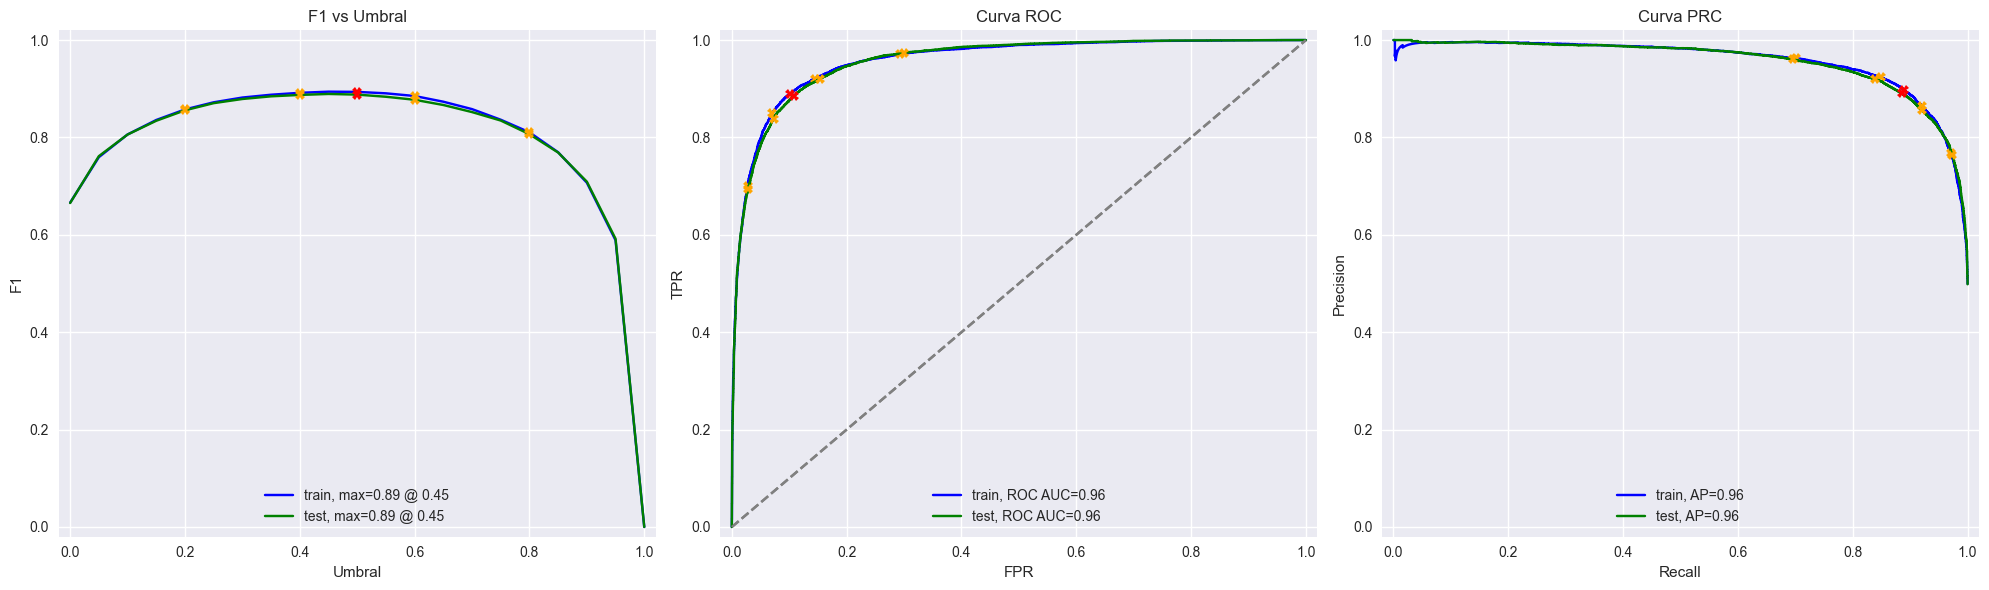

In [30]:
evaluate_model(model_6, train_features_bert, train_target, test_features_bert, test_target);

## 8. Tabla comparativa de modelos

In [31]:
# resultados = [r for r in resultados if r['Modelo'] != '6 - BERT + LR']  

In [32]:
# Crear tabla comparativa con todos los resultados
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.set_index('Modelo')

print('RESUMEN DE RESULTADOS')

# Mostrar tabla con formato: mejor métrica en azul, menor tiempo en azul
display(
    df_resultados.style
    .highlight_max(subset=['F1 Test', 'Accuracy Test', 'ROC AUC Test'], color='blue')
    .highlight_min(subset=['Tiempo Train (s)', 'Tiempo Pred (s)'], color='blue')
    .format(precision=4, subset=['F1 Test', 'Accuracy Test', 'ROC AUC Test'])
    .format(precision=2, subset=['Tiempo Train (s)', 'Tiempo Pred (s)'])
)

# Identificar modelos que cumplen el objetivo
print(f'\nModelos que alcanzan F1 >= 0.85:')
alcanzaron = df_resultados[df_resultados['F1 Test'] >= 0.85]
if len(alcanzaron) > 0:
    for nombre, row in alcanzaron.iterrows():
        print(f'  - {nombre}: F1 = {row["F1 Test"]:.4f}')
else:
    print('  Ningún modelo alcanzó el objetivo.')

mejor = df_resultados['F1 Test'].idxmax()
print(f'\nMejor modelo: {mejor} (F1 = {df_resultados.loc[mejor, "F1 Test"]:.4f})')

RESUMEN DE RESULTADOS


,F1 Test,Accuracy Test,ROC AUC Test,Tiempo Train (s),Tiempo Pred (s)
Modelo,,,,,
0 - Dummy (Baseline),0.0000,0.5015,0.5000,0.00,0.00
1 - TF-IDF word + LR,0.8784,0.8783,0.9499,0.46,0.01
2 - TF-IDF char + LR,0.8844,0.8847,0.9546,7.19,0.11
3 - TF-IDF word + RF,0.8564,0.8582,0.9342,15.33,1.48
4 - TF-IDF word + CNB,0.8450,0.8509,0.9304,0.04,0.03
5 - spaCy + LGBM,0.8717,0.8723,0.9456,69.11,0.69
6 - BERT + LR,0.8880,0.8887,0.9567,1.03,0.05



Modelos que alcanzan F1 >= 0.85:
  - 1 - TF-IDF word + LR: F1 = 0.8784
  - 2 - TF-IDF char + LR: F1 = 0.8844
  - 3 - TF-IDF word + RF: F1 = 0.8564
  - 5 - spaCy + LGBM: F1 = 0.8717
  - 6 - BERT + LR: F1 = 0.8880

Mejor modelo: 6 - BERT + LR (F1 = 0.8880)


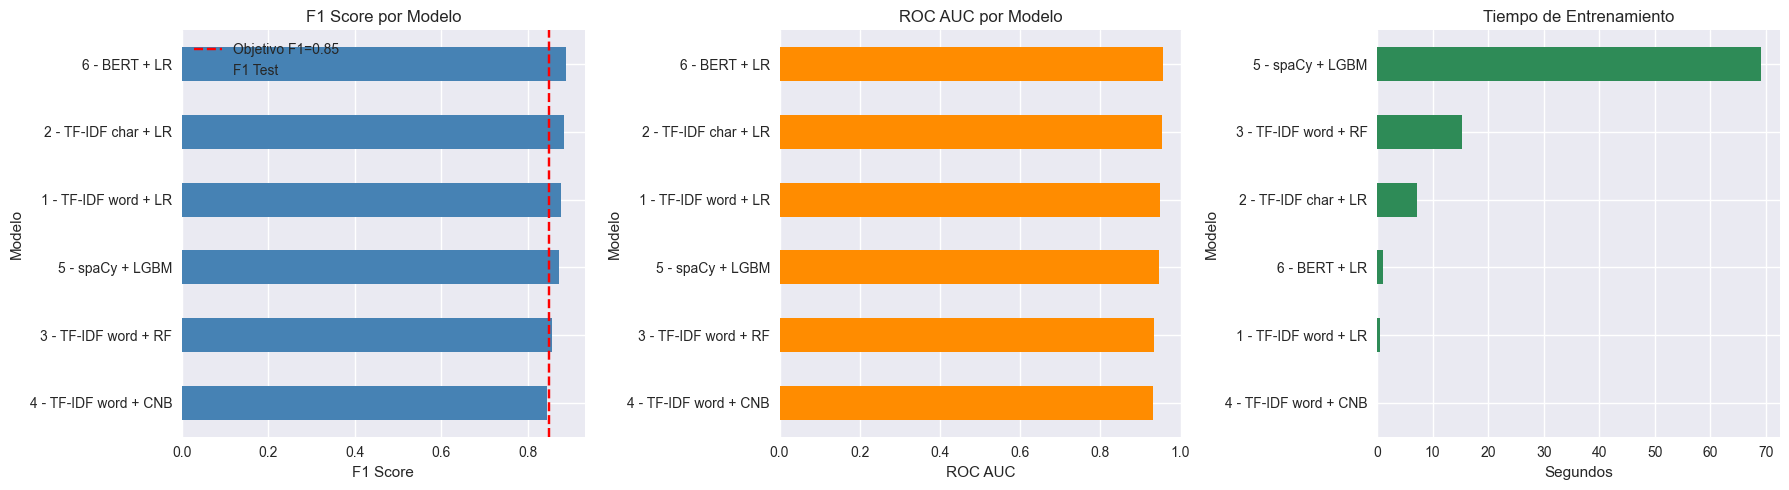

In [33]:
# Gráficos comparativos de los modelos (sin el baseline)
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

df_plot = df_resultados.drop(index='0 - Dummy (Baseline)', errors='ignore')

# Gráfico 1: F1 Score con línea de objetivo
ax = axes[0]
df_plot['F1 Test'].sort_values().plot.barh(ax=ax, color='steelblue')
ax.axvline(x=0.85, color='red', linestyle='--', label='Objetivo F1=0.85')
ax.set_xlabel('F1 Score')
ax.set_title('F1 Score por Modelo')
ax.legend()

# Gráfico 2: ROC AUC
ax = axes[1]
df_plot['ROC AUC Test'].sort_values().plot.barh(ax=ax, color='darkorange')
ax.set_xlabel('ROC AUC')
ax.set_title('ROC AUC por Modelo')

# Gráfico 3: Tiempo de entrenamiento
ax = axes[2]
df_plot['Tiempo Train (s)'].sort_values().plot.barh(ax=ax, color='seagreen')
ax.set_xlabel('Segundos')
ax.set_title('Tiempo de Entrenamiento')

fig.tight_layout()
plt.show()

## 9. Prueba con reseñas propias

In [34]:
# Reseñas de prueba escritas manualmente para validar los modelos
my_reviews = pd.DataFrame([
    'I did not simply like it, not my kind of movie.',
    'Well, I was bored and felt asleep in the middle of the movie.',
    'I was really fascinated with the movie',
    'Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.',
    "I didn't expect the reboot to be so good! Writers really cared about the source material",
    "The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.",
    'What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won\'t like this!',
    'Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.'
], columns=['review'])

# Normalizar y asignar etiquetas esperadas
my_reviews['review_norm'] = my_reviews['review'].apply(normalize_text)
my_reviews['expected'] = ['neg', 'neg', 'pos', 'neg', 'pos', 'pos', 'neg', 'pos']
my_reviews

,review,review_norm,expected
0,"I did not simply like it, not my kind of movie.",i did not simply like it not my kind of movie,neg
1,"Well, I was bored and felt asleep in the middl...",well i was bored and felt asleep in the middle...,neg
2,I was really fascinated with the movie,i was really fascinated with the movie,pos
3,Even the actors looked really old and disinter...,even the actors looked really old and disinter...,neg
4,I didn't expect the reboot to be so good! Writ...,i didn t expect the reboot to be so good write...,pos
5,"The movie had its upsides and downsides, but I...",the movie had its upsides and downsides but i ...,pos
6,What a rotten attempt at a comedy. Not a singl...,what a rotten attempt at a comedy not a single...,neg
7,Launching on Netflix was a brave move & I real...,launching on netflix was a brave move i really...,pos


### Predicciones de cada modelo sobre las reseñas propias

In [35]:
# Diccionario con todos los modelos y sus funciones de transformación
modelos_test = {
    'M1 LR word': (model_1, lambda t: tfidf_word.transform(t)),
    'M2 LR char': (model_2, lambda t: tfidf_char.transform(t)),
    'M3 RF':      (model_3, lambda t: tfidf_word.transform(t)),
    'M4 CNB':     (model_4, lambda t: tfidf_word.transform(t)),
    'M5 LGBM':    (model_5, lambda t: tfidf_spacy.transform(t)),
    'M6 BERT':    (model_6, lambda t: bert_text_to_embeddings(t, batch_size=8)),
}

# Preparar texto con preprocesamiento ligero para BERT
my_reviews['review_bert'] = my_reviews['review'].astype(str).map(normalize_for_bert)

# Obtener probabilidades de cada modelo sobre las reseñas de prueba
for nombre, (modelo, transform_fn) in modelos_test.items():
    if 'BERT' in nombre:
        texts = my_reviews['review_bert']
    else:
        texts = my_reviews['review_norm']
    features = transform_fn(texts)
    probs = modelo.predict_proba(features)[:, 1]
    my_reviews[nombre] = probs.round(3)

# Mostrar tabla con probabilidades (valores cercanos a 1 = positivo, cercanos a 0 = negativo)
cols = ['review', 'expected'] + list(modelos_test.keys())
display(my_reviews[cols].style.format(precision=3, subset=list(modelos_test.keys())))

BERT embeddings: 100%|██████████| 1/1 [00:00<00:00,  9.37it/s]


,review,expected,M1 LR word,M2 LR char,M3 RF,M4 CNB,M5 LGBM,M6 BERT
0,"I did not simply like it, not my kind of movie.",neg,0.272,0.228,0.605,0.369,0.663,0.392
1,"Well, I was bored and felt asleep in the middle of the movie.",neg,0.200,0.165,0.530,0.220,0.226,0.001
2,I was really fascinated with the movie,pos,0.552,0.726,0.865,0.627,0.691,0.966
3,"Even the actors looked really old and disinterested, and they got paid to be in the movie. What a soulless cash grab.",neg,0.240,0.093,0.485,0.152,0.264,0.000
4,I didn't expect the reboot to be so good! Writers really cared about the source material,pos,0.325,0.296,0.485,0.351,0.099,0.120
5,"The movie had its upsides and downsides, but I feel like overall it's a decent flick. I could see myself going to see it again.",pos,0.414,0.628,0.620,0.382,0.648,0.780
6,"What a rotten attempt at a comedy. Not a single joke lands, everyone acts annoying and loud, even kids won't like this!",neg,0.157,0.074,0.365,0.276,0.285,0.008
7,"Launching on Netflix was a brave move & I really appreciate being able to binge on episode after episode, of this exciting intelligent new drama.",pos,0.836,0.777,0.890,0.657,0.952,1.000


## 10. Conclusiones

### Resultados

- **Objetivo cumplido:** 5 de los 7 modelos superaron el umbral de F1 >= 0.85.
- **Mejor modelo:** BERT + Logistic Regression con F1 = 0.8880 y ROC AUC = 0.9567.
- **Mejor modelo clásico:** TF-IDF char + LR con F1 = 0.8844, muy cerca de BERT pero mucho más rápido.
- **Baseline:** El DummyClassifier confirmó que las clases están balanceadas (F1 ~0.50).

### Recomendación

Para producción con baja latencia, **TF-IDF word + LR** es la mejor opción: F1 alto (0.8784), predicción casi instantánea y fácil de mantener.

Si se busca la mayor precisión posible, **BERT + LR** es el mejor modelo, especialmente para reseñas ambiguas donde la comprensión semántica marca la diferencia.


## Lista de comprobacion

- [x] Notebook abierto y ejecutado
- [x] Datos cargados y preprocesados (normalizacion de texto)
- [x] Datos transformados en vectores (TF-IDF, spaCy, BERT embeddings)
- [x] Modelos entrenados y evaluados (7 modelos)
- [x] Valor F1 >= 0.85 alcanzado
- [x] Tabla comparativa con metricas y tiempos
- [x] Reseñas propias probadas con todos los modelos
- [x] Conclusiones escritas